In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import hdbscan
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA


# -<Python STD>-
import numpy as np
import pandas as pd
import sys
import os

# -<Data Formatting>-
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import LeaveOneGroupOut

# -<Information Analysis>-
from scipy.fftpack import dct
from scipy.fftpack import dct
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from pyefd import elliptic_fourier_descriptors
from shapely.geometry import Polygon, LineString
from scipy.signal import savgol_filter
from scipy.spatial.distance import pdist

# -<Visualizing correlations>-
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import plotly.express as px
import seaborn as sns
import collections

# --<Machine Learning: Clustering>--
import umap.umap_ as umap
import torch
import hdbscan
from sklearn.manifold import trustworthiness
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import adjusted_rand_score, silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import SpectralClustering
from sklearn.cluster import KMeans


# --- Global MIT Aesthetic Settings ---
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.labelweight'] = 'bold'

# -<Do not be annoying>
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='statsmodels')
warnings.filterwarnings("ignore", category=FutureWarning, module='statsmodels')

In [3]:
class HystProcessor:
    def __init__(self, file_destinations):
        self.file_destinations = file_destinations
        self.SAMPLE_RATE_MS = 20
        self.MIN_LENGTH_READINGS = 100
        self.POST_BREATH_BUFFER = 5


    def load_npy(self, filename, description="data"):
        try:
            data = np.load(filename)
            print(f"Successfully loaded {filename}. Shape: {data.shape}")
            return data
        except FileNotFoundError:
            print(f" ERROR: Required {description} file ('{filename}') not found. ")
            sys.exit(1)
        except Exception as e:
            print(f" ERROR: Failed to load {filename}. Details: {e} ")
            sys.exit(1)


    def ComputeDuration(self, flow_arr, pressure_arr):
        lengths = []
        num_breaths, num_timesteps = flow_arr.shape
        for i in range(num_breaths):
            PaddingFound = np.logical_and(flow_arr[i] == 0, pressure_arr[i] == 0)
            last_true_index = np.where(~PaddingFound)[0]
            if last_true_index.size == 0:
                length = 0
            else:
                length = last_true_index[-1] + 1
            lengths.append(length)
        return np.array(lengths)


    def check_preprocessed_data(self):
        csv_path = self.file_destinations.get('output_csv')
        if csv_path and os.path.exists(csv_path):
            print(f"Existing processed file found at {csv_path}. Loading...")
            return pd.read_csv(csv_path)
        return None


    def process(self, save_output=False):
        cached_df = self.check_preprocessed_data()
        if cached_df is not None:
            return cached_df

        print("No processed file found. Starting processing from .npy files...")
        
        flow = self.load_npy(self.file_destinations['flow'], 'Flow Time Series')
        pressure = self.load_npy(self.file_destinations['pressure'], 'Pressure Time Series')
        trainy = self.load_npy(self.file_destinations['trainy'], 'One-Hot Target')

        InitCycle_C, num_timesteps = flow.shape
        if pressure.shape != (InitCycle_C, num_timesteps):
            print(" ERROR: Flow and Pressure array shapes do not match. ")
            sys.exit(1)
        if trainy.shape[0] != InitCycle_C:
            print(f" ERROR: Target values row count ({trainy.shape[0]}) does not match the number of breaths ({InitCycle_C}). ")
            sys.exit(1)

        num_classes = trainy.shape[1]
        print(f"\nInitial Data structural check passed. Total breaths: {InitCycle_C}, Timesteps (padded): {num_timesteps}, Classes: {num_classes}")

        true_lengths = self.ComputeDuration(flow, pressure)
        print(f"\nInferred true lengths for {len(true_lengths)} breaths.")

        ValidCycles = np.where(true_lengths >= self.MIN_LENGTH_READINGS)[0]
        print(f"Filtering: Keeping {len(ValidCycles)} breaths with length >= {self.MIN_LENGTH_READINGS} readings.")

        flow_filtered = flow[ValidCycles]
        pressure_filtered = pressure[ValidCycles]
        trainy_filtered = trainy[ValidCycles]
        true_lengths_filtered = true_lengths[ValidCycles]

        num_breaths_final = len(ValidCycles)
        all_data = []

        for i in range(num_breaths_final):
            breath_id = ValidCycles[i]
            length = true_lengths_filtered[i]
            end_index = min(length + self.POST_BREATH_BUFFER, num_timesteps)

            flow_slice = flow_filtered[i, :end_index]
            pressure_slice = pressure_filtered[i, :end_index]
            num_points = end_index

            time_ms = np.arange(num_points) * self.SAMPLE_RATE_MS
            targets = np.tile(trainy_filtered[i], (num_points, 1))

            temp_df = pd.DataFrame({
                'Breath_ID': breath_id,
                'Time_Step': np.arange(num_points),
                'Time_ms': time_ms,
                'Flow': flow_slice,
                'Pressure': pressure_slice,
            })

            temp_df[[f'Target_Class_{c}' for c in range(num_classes)]] = targets
            all_data.append(temp_df)

        df_processed = pd.concat(all_data, ignore_index=True)

        print("\n Final Processed DataFrame Head (Filtered and Truncated) ")
        print(f"Final Data Shape: {df_processed.shape}")
        
        if save_output and 'output_csv' in self.file_destinations:
            output_file = self.file_destinations['output_csv']
            df_processed.to_csv(output_file, index=False)
            print(f"\n✅ Final, combined dataset saved to '{output_file}'.")

        return df_processed

config_destinations = {
    'flow': 'flow.npy',
    'pressure': 'pressure.npy',
    'trainy': 'trainy_all.npy',
    'output_csv': 'PAV_dataset.csv'
}

processor = HystProcessor(config_destinations)
Dataset = processor.process(save_output=True)

Existing processed file found at PAV_dataset.csv. Loading...


In [4]:
Dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1272587 entries, 0 to 1272586
Data columns (total 10 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   Breath_ID       1272587 non-null  int64  
 1   Time_Step       1272587 non-null  int64  
 2   Time_ms         1272587 non-null  int64  
 3   Flow            1272587 non-null  float64
 4   Pressure        1272587 non-null  float64
 5   Target_Class_0  1272587 non-null  int64  
 6   Target_Class_1  1272587 non-null  int64  
 7   Target_Class_2  1272587 non-null  int64  
 8   Target_Class_3  1272587 non-null  int64  
 9   Target_Class_4  1272587 non-null  int64  
dtypes: float64(2), int64(8)
memory usage: 97.1 MB


In [5]:
class StaticFeatureExtraction:
    def __init__(self, num_efd_harmonics=3, num_dct_coeffs=3):
        # Reduced harmonics from 10 to 3 to focus on global shape, not jitter
        self.num_harmonics = num_efd_harmonics
        self.num_dct_coeffs = num_dct_coeffs

    def extract_all(self, df):
        feature_list = []
        for breath_id, group in df.groupby('Breath_ID'):
            x = group['Flow'].values
            y = group['Pressure'].values
            
            # Physical/Geometric Features
            area = 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))
            rem_eq = np.mean(np.abs(y[np.isclose(x, 0, atol=0.1)])) if any(np.isclose(x, 0, atol=0.1)) else 0
            coer_eq = np.mean(np.abs(x[np.isclose(y, 0, atol=0.1)])) if any(np.isclose(y, 0, atol=0.1)) else 0
            
            dx_dt, dy_dt = np.gradient(x), np.gradient(y)
            curvature = np.mean(np.abs(dx_dt * np.gradient(dy_dt) - dy_dt * np.gradient(dx_dt)) / (dx_dt**2 + dy_dt**2 + 1e-6)**1.5)
            
            x_c, y_c = x - np.mean(x), y - np.mean(y)
            phase_vel = np.mean(np.abs(np.gradient(np.unwrap(np.arctan2(y_c, x_c)))))

            feat_dict = {
                'Breath_ID': breath_id,
                'Loop_Area': area,
                'Remanence_Eq': rem_eq,
                'Coercivity_Eq': coer_eq,
                'Mean_Curvature': curvature,
                'Phase_Velocity': phase_vel
            }
            
            # Shape Descriptors (Reduced set)
            coeffs = elliptic_fourier_descriptors(np.column_stack([x, y]), order=self.num_harmonics, normalize=True)
            for i, val in enumerate(coeffs.flatten()): feat_dict[f'EFD_{i}'] = val
            
            dct_x = dct(x, type=2, norm='ortho')[:self.num_dct_coeffs]
            for i, val in enumerate(dct_x): feat_dict[f'DCT_X_{i}'] = val
            
            feature_list.append(feat_dict)
            
        return pd.DataFrame(feature_list)

In [6]:
class StreamlinedPCA:
    def __init__(self, n_components=10):
        self.pca = PCA(n_components=n_components)
        self.loadings = None

    def fit_transform(self, data):
        transformed = self.pca.fit_transform(data)
        self.loadings = pd.DataFrame(self.pca.components_.T, 
                                     columns=[f'PC{i+1}' for i in range(self.pca.n_components_)],
                                     index=data.columns)
        return transformed

    def plot_variance(self):
        plt.figure(figsize=(10, 6))
        exp_var = self.pca.explained_variance_ratio_
        cum_var = np.cumsum(exp_var)
        
        bars = plt.bar(range(1, len(exp_var) + 1), exp_var, alpha=0.8, color='skyblue', label='Individual')
        plt.plot(range(1, len(exp_var) + 1), cum_var, marker='o', linestyle='--', color='salmon', label='Cumulative')

        for i, (bar, cv) in enumerate(zip(bars, cum_var)):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{exp_var[i]:.3f}', ha='center', va='bottom')
            plt.text(i + 1, cv, f'{cv:.3f}', ha='center', va='bottom')

        plt.title('Explained Variance by Principal Component')
        plt.xlabel('PC Number'); plt.ylabel('Variance Ratio'); plt.legend(); plt.grid(True)
        plt.tight_layout()
        plt.show()

    def plot_loadings_heatmap(self, n_pcs=5):
        plt.figure(figsize=(12, 8))
        sorted_loadings = self.loadings.sort_values(by='PC1', ascending=False)
        sns.heatmap(sorted_loadings.iloc[:, :n_pcs], annot=True, cmap='viridis', fmt=".3f")
        plt.title(f'Feature Loadings (Top {n_pcs} PCs)')
        plt.tight_layout(); plt.show()

    def run_kaiser_threshold(self):
        eigenvalues = self.pca.explained_variance_
        above_threshold = eigenvalues > 1
        
        results_df = pd.DataFrame({
            'Eigenvalue': eigenvalues,
            'Above_Kaiser': above_threshold,
            'Var_Explained': self.pca.explained_variance_ratio_,
            'Cum_Var': np.cumsum(self.pca.explained_variance_ratio_)
        }, index=[f'PC-{i+1}' for i in range(len(eigenvalues))])

        print("\n--- Kaiser-Guttman Analysis ---")
        print(results_df)
        
        significant_pcs = results_df[results_df['Above_Kaiser']].index.tolist()
        for pc in significant_pcs:
            top_3 = self.loadings[pc.replace('-', '')].abs().sort_values(ascending=False).head(3)
            print(f"\nTop 3 for {pc}:")
            for feat in top_3.index:
                print(f"  - {feat}: {self.loadings.loc[feat, pc.replace('-', '')]:.4f}")

In [7]:
extractor = StaticFeatureExtraction()
Hyster_Features = extractor.extract_all(Dataset).drop(columns=['Breath_ID'])

# Filter out constant features
constant_filter = Hyster_Features.std() > 0
Hyster_Features_Filtered = Hyster_Features.loc[:, constant_filter]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(Hyster_Features_Filtered)
X_scaled_df = pd.DataFrame(X_scaled, columns=Hyster_Features_Filtered.columns)

# FEATURE WEIGHTING: Boost biological importance
# We multiply the 'Physical' features by 3 to give them more 'variance' than the Fourier noise
physical_cols = ['Loop_Area', 'Remanence_Eq', 'Coercivity_Eq', 'Mean_Curvature', 'Phase_Velocity']
existing_phys = [c for c in physical_cols if c in X_scaled_df.columns]
X_scaled_df[existing_phys] *= 3.0

X_scaled_df = X_scaled_df.fillna(0)

/home/molderon/micromamba/envs/Kaon/lib/python3.10/site-packages/pyefd.py:67: RuntimeWarning: invalid value encountered in divide
  a = consts * np.sum((dxy[:, 0] / dt) * d_cos_phi, axis=1)
/home/molderon/micromamba/envs/Kaon/lib/python3.10/site-packages/pyefd.py:68: RuntimeWarning: invalid value encountered in divide
  b = consts * np.sum((dxy[:, 0] / dt) * d_sin_phi, axis=1)
/home/molderon/micromamba/envs/Kaon/lib/python3.10/site-packages/pyefd.py:69: RuntimeWarning: invalid value encountered in divide
  c = consts * np.sum((dxy[:, 1] / dt) * d_cos_phi, axis=1)
/home/molderon/micromamba/envs/Kaon/lib/python3.10/site-packages/pyefd.py:70: RuntimeWarning: invalid value encountered in divide
  d = consts * np.sum((dxy[:, 1] / dt) * d_sin_phi, axis=1)


In [8]:
X_scaled_df.head()

,Loop_Area,Remanence_Eq,Coercivity_Eq,Mean_Curvature,Phase_Velocity,DCT_X_0,DCT_X_1,DCT_X_2
0,4.378120,-1.525141,-0.079245,-0.496258,1.773714,0.318488,-0.047739,-0.197760
1,4.313985,-1.525141,-0.079245,-0.497368,4.799429,0.130929,-0.369779,-0.307226
2,4.913222,4.074053,-0.079245,-0.527533,7.213674,0.419604,-0.201437,-0.217193
3,5.924681,-1.525141,-0.079245,-0.538573,7.260120,1.002777,-0.104557,-1.353493
4,3.657970,-1.525141,-0.079245,-0.507752,5.533477,0.108794,-0.200510,-1.053055


In [9]:
spca = StreamlinedPCA(n_components=6) 
X_pca = spca.fit_transform(X_scaled_df)
spca.run_kaiser_threshold()


--- Kaiser-Guttman Analysis ---
      Eigenvalue  Above_Kaiser  Var_Explained   Cum_Var
PC-1   10.321261          True       0.214998  0.214998
PC-2    9.162165          True       0.190854  0.405852
PC-3    9.047599          True       0.188467  0.594320
PC-4    8.791816          True       0.183139  0.777459
PC-5    8.164977          True       0.170082  0.947540
PC-6    1.360992          True       0.028350  0.975891

Top 3 for PC-1:
  - Phase_Velocity: 0.6900
  - Loop_Area: 0.5375
  - Remanence_Eq: 0.4261

Top 3 for PC-2:
  - Coercivity_Eq: 0.8205
  - Remanence_Eq: -0.4557
  - Mean_Curvature: -0.2417

Top 3 for PC-3:
  - Mean_Curvature: 0.8146
  - Coercivity_Eq: 0.3808
  - Loop_Area: -0.3482

Top 3 for PC-4:
  - Remanence_Eq: 0.6911
  - Mean_Curvature: -0.5144
  - Loop_Area: -0.4462

Top 3 for PC-5:
  - Phase_Velocity: 0.6499
  - Loop_Area: -0.6211
  - Coercivity_Eq: -0.3458

Top 3 for PC-6:
  - DCT_X_0: 0.7030
  - DCT_X_1: 0.6782
  - DCT_X_2: 0.1554


In [10]:
class RespiratoryPhenotyper:
    def __init__(self, n_pcs=5, min_cluster_size=100, min_samples=25): # Higher cluster size, lower samples
        self.n_pcs = n_pcs
        self.min_cluster_size = min_cluster_size 
        self.min_samples = min_samples             

    def fit(self, pca_data):

        cluster_reducer = umap.UMAP(
            n_neighbors=250,       # High value for "Global" physiological patterns
            n_components=2,        
            min_dist=0,         # Prevents "infinite density" needles
            metric='cosine',       # Better for Fourier/DCT coefficient relationships
            random_state=42,
            low_memory=False ,     # Use if your dataset is large
            n_jobs=-1
        )
        cluster_embedding = cluster_reducer.fit_transform(pca_data[:, :self.n_pcs])

        self.clusterer = hdbscan.HDBSCAN(
            min_cluster_size=self.min_cluster_size,
            min_samples=self.min_samples,
            cluster_selection_method='eom',
            prediction_data=True # Ensure this is True to get probabilities
        )
        self.labels = self.clusterer.fit_predict(cluster_embedding)
        
        # ADD THIS LINE:
        self.probs = self.clusterer.probabilities_ 
        
        self.vis_embedding = cluster_embedding
        return self


    def plot_summary(self, top_n_labels=15):
        if self.labels is None:
            raise ValueError("Run .fit() first.")

        # Setup aesthetics
        sns.set_context("paper", font_scale=1.1)
        # Changed style to "whitegrid" or keep "ticks" and force grid visibility
        sns.set_style("ticks") 
        fig, ax = plt.subplots(figsize=(11, 8))
        
        mask_noise = (self.labels == -1)
        mask_clusters = (self.labels != -1)
        unique_labels = sorted([l for l in np.unique(self.labels) if l != -1])
        n_clusters = len(unique_labels)

        # Identify top N clusters to label
        cluster_counts = collections.Counter(self.labels[mask_clusters])
        top_clusters = [cid for cid, count in cluster_counts.most_common(top_n_labels)]
        
        # Colour palette
        pal = sns.color_palette("husl", n_colors=n_clusters)
        color_map = {label: pal[i] for i, label in enumerate(unique_labels)}

        # Layer 1: Noise
        ax.scatter(
            self.vis_embedding[mask_noise, 0], self.vis_embedding[mask_noise, 1],
            color='black', marker='x', s=35, alpha=0.2,
            linewidths=0.5, label='Noise', zorder=1
        )
        
        # Layer 2: Clusters
        ax.scatter(
            self.vis_embedding[mask_clusters, 0], self.vis_embedding[mask_clusters, 1],
            c=[color_map[l] for l in self.labels[mask_clusters]],
            s=25 * self.probs[mask_clusters], alpha=0.5,
            edgecolor='none', zorder=2
        )

        # Layer 3: Selective centroid labelling
        for l in top_clusters:
            idx = (self.labels == l)
            centroid = np.median(self.vis_embedding[idx], axis=0)
            ax.annotate(
                f"C{l}", centroid,
                weight='bold', fontsize=9,
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color_map[l], alpha=0.9, lw=1.5),
                zorder=4
            )

        # Formatting
        ax.set_title("Manifold Topology of Respiratory Phenotypes",
                    loc='left', fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='bold')
        ax.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='bold')

        # --- GRID ADJUSTMENTS ---
        ax.grid(True, linestyle='--', alpha=0.3, zorder=0) # Added zorder=0 to keep it behind data
        ax.set_axisbelow(True) # Ensures grid stays behind the scatter points
        
        ax.legend(loc='upper right', frameon=True, fontsize='small', markerscale=1.5)
        sns.despine(trim=True) # Trimmed looks slightly cleaner with grids
        plt.tight_layout()
        plt.show()

    def evaluate(self, original_pca_data):

        mask = (self.labels != -1)
        n_labeled = np.sum(mask)

        if n_labeled < 2:
            print("Warning: Not enough clusters found to calculate performance metrics.")
            return None

        # Use the 2D visualisation embedding for metric evaluation
        X_eval = self.vis_embedding[mask]
        y_eval = self.labels[mask]

        sil = silhouette_score(X_eval, y_eval)
        dbi = davies_bouldin_score(X_eval, y_eval)
        chi = calinski_harabasz_score(X_eval, y_eval)

        try:
            dbcv = self.clusterer.relative_validity_
        except Exception:
            dbcv = np.nan

        noise_ratio = np.mean(self.labels == -1)

        # Trustworthiness: how well the 2D projection preserves neighbourhoods from original PCA space
        sample_size = min(len(original_pca_data), 5000)
        idx = np.random.choice(len(original_pca_data), sample_size, replace=False)
        trust = trustworthiness(
            original_pca_data[idx, :self.n_pcs],
            self.vis_embedding[idx],
            n_neighbors=10
        )

        print(f"\n{'Performance Metric':<25} | {'Value':<10}")
        print("-" * 40)
        print(f"{'Silhouette Score':<25} | {sil:>10.4f}")
        print(f"{'Davies-Bouldin Index':<25} | {dbi:>10.4f}")
        print(f"{'Calinski-Harabasz Index':<25} | {chi:>10.4f}")
        print(f"{'DBCV (Density Validity)':<25} | {dbcv:>10.4f}")
        print(f"{'Manifold Trustworthiness':<25} | {trust:>10.4f}")
        print(f"{'Noise Ratio':<25} | {noise_ratio:>10.4f}")

        return {
            "Silhouette": sil,
            "DBI": dbi,
            "CHI": chi,
            "DBCV": dbcv,
            "Trustworthiness": trust,
            "Noise": noise_ratio
        }

/home/molderon/micromamba/envs/Kaon/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


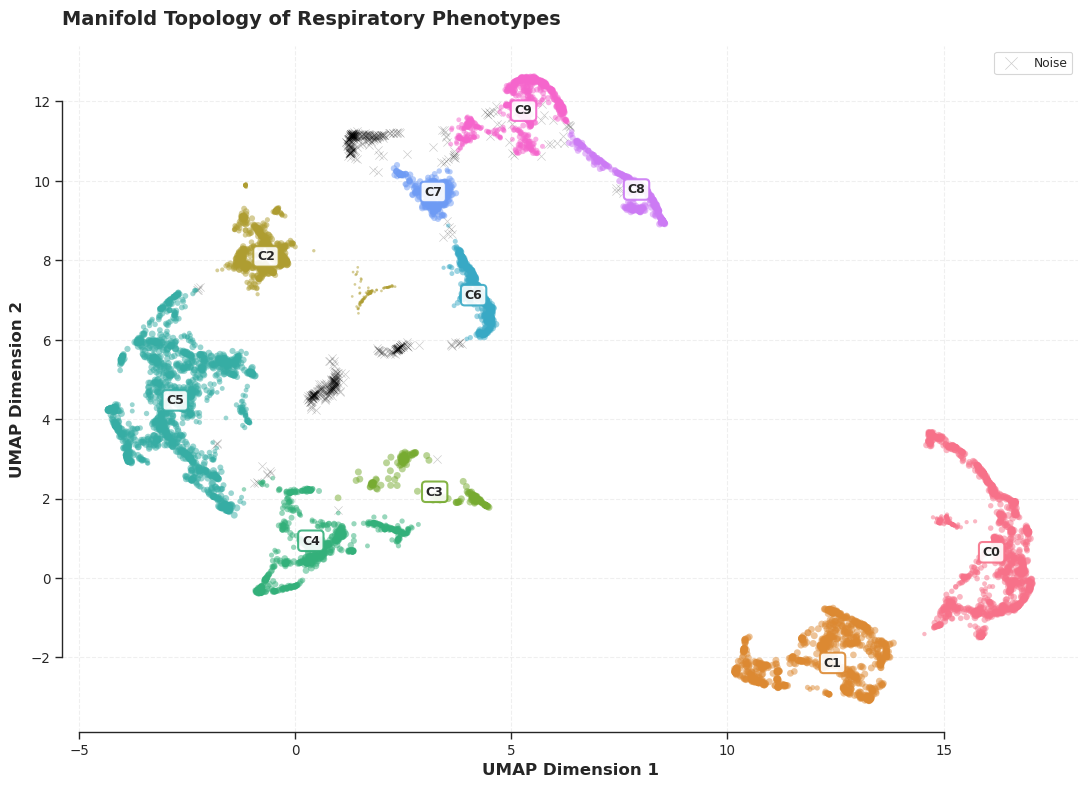


Performance Metric        | Value     
----------------------------------------
Silhouette Score          |     0.5723
Davies-Bouldin Index      |     0.5456
Calinski-Harabasz Index   | 29903.8516
DBCV (Density Validity)   |        nan
Manifold Trustworthiness  |     0.9675
Noise Ratio               |     0.0711


In [11]:
phenotyper = RespiratoryPhenotyper(n_pcs=18, min_cluster_size=210, min_samples=20)
phenotyper.fit(X_pca)

phenotyper.plot_summary(top_n_labels=16)
metrics = phenotyper.evaluate(X_pca)

# Respiratory Waveform Clustering Pipeline Documentation

This documentation describes the architecture and workflow of the `BreathClusteringPipeline`. This system is designed for the unsupervised discovery of breathing patterns (phenotypes) from mechanical ventilation data using Deep Learning.

---

## 🏗️ Architecture Overview

The pipeline uses a **Deep Autoencoder** to compress high-dimensional respiratory time-series into a low-dimensional "latent" space, followed by density-based clustering.

### 1. The Model: `BreathAutoencoder`
The model is a symmetric Multi-Layer Perceptron (MLP) designed to compress and then reconstruct waveforms.

* **Input Layer:** Accepts a flattened vector of size $target\_len \times 2$ (representing concatenated Flow and Pressure).
* **Encoder:** * `Linear(input_dim -> 512) -> ReLU`
    * `Linear(512 -> 128) -> ReLU`
    * `Linear(128 -> latent_dim)`: The bottleneck layer (default 16 units).
* **Decoder:** * `Linear(latent_dim -> 128) -> ReLU`
    * `Linear(128 -> 512) -> ReLU`
    * `Linear(512 -> input_dim)`: Reconstructs the original flattened signal.



---

## ⚙️ The Workflow: `BreathClusteringPipeline`

The `run()` method orchestrates the following five stages:

### Stage 1: Preprocessing (`preprocess`)
Raw, unevenly sampled data is transformed into a standardized tensor format.
1.  **Breath Segmentation:** Groups the dataframe by `Breath_ID`.
2.  **Fixed-Length Resampling:** Uses linear interpolation (`np.linspace`) to ensure every breath has exactly `target_len` (default 200) data points, regardless of original duration.
3.  **Standardization:** Uses `StandardScaler` to remove mean and scale to unit variance for both Flow and Pressure.

### Stage 2: Feature Learning (`train_autoencoder`)
The model is trained using **Self-Supervised Learning**.
* **Loss Function:** Mean Squared Error (MSE), measuring the difference between the original and reconstructed waveforms.
* **Optimizer:** Adam optimizer with a learning rate of $10^{-3}$.
* **Goal:** To force the model to prioritize the most important morphological features of the breath in the latent bottleneck.

### Stage 3: Feature Extraction (`extract_latent`)
The decoder is bypassed, and the first half of the model (the encoder) is used to map each breath into a 16-dimensional vector. This "Latent Vector" represents the "DNA" of that specific breath.

### Stage 4: Discovery and Clustering (`cluster`)
The pipeline uses **HDBSCAN** (Hierarchical Density-Based Spatial Clustering of Applications with Noise).
* **Advantages:** Unlike K-Means, it doesn't require pre-specifying the number of clusters and can identify "outlier" breaths as noise (labeled as `-1`).
* **Parameters:** `min_cluster_size=100` ensures that discovered phenotypes are statistically significant.

### Stage 5: Visualization & Audit (`visualize` & `plot_clusters`)
1.  **UMAP Projection:** Projects the 16D latent space into 2D for visual inspection of cluster separation.
2.  **Mean Waveform Inspection:** Generates plots of the average Flow and Pressure curves for each cluster. This allows for clinical labeling (e.g., "Cluster 1 = Normal", "Cluster 2 = Ineffective Effort").



---

## 🚀 Usage

```python
# Initialize
pipeline = BreathClusteringPipeline(target_len=200, latent_dim=16, epochs=10)

# Execute on DataFrame containing 'Breath_ID', 'Flow', and 'Pressure'
results = pipeline.run(df)

# Output Analysis
print(f"Total breaths processed: {len(results['labels'])}")

In [12]:
# --- Global Aesthetic Config ---
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['font.family'] = 'serif'

# --------------------------------------------------
# CNN AUTOENCODER
# --------------------------------------------------import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import hdbscan
import collections
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import trustworthiness

# --------------------------------------------------
# CNN AUTOENCODER
# --------------------------------------------------
class CNNAutoencoder(nn.Module):
    def __init__(self, target_len=200, latent_dim=32):
        super().__init__()
        self.target_len = target_len
        self.latent_dim = latent_dim

        # Encoder: Extracts morphological features
        self.encoder = nn.Sequential(
            nn.Conv1d(2, 16, 5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, 5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 5, padding=2),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * (target_len // 4), latent_dim)
        )

        # Decoder: Latent -> Feature Map
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64 * (target_len // 4)),
            nn.ReLU()
        )

        # Deconv: Feature Map -> Waveform
        self.deconv = nn.Sequential(
            nn.ConvTranspose1d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(32, 16, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv1d(16, 2, 3, padding=1)
        )

    def forward(self, x):
        # Permute to (Batch, Channels, Length) for Conv1d
        x = x.permute(0, 2, 1)
        latent = self.encoder(x)
        recon = self.decoder(latent)
        recon = recon.reshape(-1, 64, self.target_len // 4)
        recon = self.deconv(recon)
        # Permute back to (Batch, Length, Channels) for Loss/Viz
        recon = recon.permute(0, 2, 1)
        return recon, latent

# --------------------------------------------------
# MAIN RESEARCH PIPELINE
# --------------------------------------------------
class DeepBreathClustering:
    def __init__(self, target_len=200, latent_dim=32, epochs=100, batch_size=128, min_cluster_size=40):
        self.target_len = target_len
        self.latent_dim = latent_dim
        self.epochs = epochs
        self.batch_size = batch_size
        self.min_cluster_size = min_cluster_size
        self.scaler = StandardScaler()
        self.model = CNNAutoencoder(target_len=target_len, latent_dim=latent_dim)

    def preprocess(self, df):
        breaths = []
        processed_ids = [] # TRACKER ADDED
        # Ensure data is sorted for linear interpolation
        for breath_id, group in df.groupby("Breath_ID"):
            flow, pressure = group["Flow"].values, group["Pressure"].values
            if len(flow) < 10: continue # Noise filter
            
            idx = np.linspace(0, len(flow)-1, self.target_len).astype(int)
            breath = np.stack([flow[idx], pressure[idx]], axis=1)
            breaths.append(breath)
            processed_ids.append(breath_id) # TRACKER ADDED
            
        breaths = np.array(breaths)
        # Global standardization across channels
        orig_shape = breaths.shape
        breaths = self.scaler.fit_transform(breaths.reshape(-1, 2)).reshape(orig_shape)
        return breaths, processed_ids # RETURN TRACKER

    def train_autoencoder(self, breaths, verbose=True):
        X = torch.tensor(breaths, dtype=torch.float32)
        loader = DataLoader(TensorDataset(X), batch_size=self.batch_size, shuffle=True)
        optimizer = torch.optim.Adam(self.model.parameters(), lr=1e-3)
        criterion = nn.MSELoss()

        self.model.train()
        for epoch in range(self.epochs):
            total_loss = 0
            for (x,) in loader:
                optimizer.zero_grad()
                recon, _ = self.model(x)
                loss = criterion(recon, x)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            if verbose and epoch % 10 == 0:
                print(f"Epoch {epoch} | Loss: {total_loss:.6f}")
        return total_loss

    def extract_latent(self, breaths):
        self.model.eval()
        X = torch.tensor(breaths, dtype=torch.float32)
        latents = []
        with torch.no_grad():
            # Batch inference to prevent OOM
            for i in range(0, len(X), 512):
                _, z = self.model(X[i:i+512])
                latents.append(z.numpy())
        return np.concatenate(latents)

    def cluster(self, latents, n_pcs=10):
        # 1. PCA Denoising (The peer-reviewed standard)
        pca = PCA(n_components=n_pcs)
        z_pca = pca.fit_transform(normalize(latents))

        # 2. Intermediate Dimension UMAP for Clustering
        reducer = umap.UMAP(n_neighbors=30, min_dist=0.0, n_components=10, random_state=42)
        embedding_high = reducer.fit_transform(z_pca)

        # 3. HDBSCAN
        clusterer = hdbscan.HDBSCAN(min_cluster_size=self.min_cluster_size, min_samples=10, prediction_data=True)
        labels = clusterer.fit_predict(embedding_high)
        probs = clusterer.probabilities_
        
        return labels, embedding_high, z_pca, probs

    def ClusteringWorkflow(self, latents, n_pcs=12):
        # 1. Normalize and Denoise Latents
        latents_norm = normalize(latents) 
        pca = PCA(n_components=n_pcs)
        z_pca = pca.fit_transform(latents_norm)

        # 2. Dimensionality Reduction for CLUSTERING (5D)
        cluster_reducer = umap.UMAP(
            n_neighbors=30,
            min_dist=0.0, 
            n_components=5, 
            metric='cosine', 
            random_state=42
        )
        cluster_embedding = cluster_reducer.fit_transform(z_pca)

        # 3. HDBSCAN on the 5D embedding
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=self.min_cluster_size,
            min_samples=10,
            prediction_data=True,
            gen_min_span_tree=True
        )
        labels = clusterer.fit_predict(cluster_embedding)
        probs = clusterer.probabilities_

        # 4. Dimensionality Reduction for VISUALIZATION (2D)
        vis_reducer = umap.UMAP(n_components=2, random_state=42)
        vis_embedding = vis_reducer.fit_transform(z_pca)

        return labels, probs, vis_embedding, cluster_embedding, z_pca

    # Version 1 of evaluate_performance
    def evaluate_performance_v1(self, high_d_data, cluster_space, labels):
        mask = labels != -1
        if np.sum(mask) < 2 or len(np.unique(labels[mask])) < 2:
            print("Warning: Not enough clusters to calculate metrics.")
            return {"Noise Ratio": np.mean(labels == -1)}
            
        X_clustered = cluster_space[mask]
        y_clustered = labels[mask]
        
        metrics = {
            "Noise Ratio": np.mean(labels == -1),
            "Silhouette Score": silhouette_score(X_clustered, y_clustered),
            "Davies-Bouldin": davies_bouldin_score(X_clustered, y_clustered),
            "Calinski-Harabasz": calinski_harabasz_score(X_clustered, y_clustered),
            "Trustworthiness": trustworthiness(high_d_data, cluster_space, n_neighbors=15)
        }

        print(f"\n{'Metric':<25} | {'Value':<10}")
        print("-" * 40)
        for k, v in metrics.items():
            print(f"{k:<25} | {v:.4f}")
        return metrics

    def PlotClusters(self, z_pca, labels, probs, top_n_labels=15):
        reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
        vis_2d = reducer.fit_transform(z_pca)
        sns.set_context("paper", font_scale=1.1)
        sns.set_style("ticks")
        fig, ax = plt.subplots(figsize=(11, 8))
        mask_noise = (labels == -1)
        mask_clusters = (labels != -1)
        unique_labels = sorted([l for l in np.unique(labels) if l != -1])
        n_clusters = len(unique_labels)
        cluster_counts = collections.Counter(labels[mask_clusters])
        top_clusters = [cid for cid, count in cluster_counts.most_common(top_n_labels)]
        pal = sns.color_palette("husl", n_colors=n_clusters)
        color_map = {label: pal[i] for i, label in enumerate(unique_labels)}

        ax.scatter(vis_2d[mask_noise, 0], vis_2d[mask_noise, 1], color='black', marker='x', s=35, alpha=0.2, label='Noise', zorder=1)
        ax.scatter(vis_2d[mask_clusters, 0], vis_2d[mask_clusters, 1], c=[color_map[l] for l in labels[mask_clusters]], s=25 * probs[mask_clusters], alpha=0.5, edgecolor='none', zorder=2)

        for l in top_clusters:
            idx = (labels == l)
            centroid = np.median(vis_2d[idx], axis=0)
            ax.annotate(f"C{l}", centroid, weight='bold', fontsize=9, ha='center', va='center', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color_map[l], alpha=0.9, lw=1.5), zorder=4)

        plt.title("Manifold Topology of Respiratory Phenotypes", loc='left', fontsize=14, fontweight='bold', pad=15)
        plt.xlabel('UMAP Dimension 1', fontsize=12, fontweight='bold')
        plt.ylabel('UMAP Dimension 2', fontsize=12, fontweight='bold')
        plt.grid(True, linestyle=':', alpha=0.4)
        plt.legend(loc='upper right', frameon=True, fontsize='small', markerscale=1.5)
        sns.despine()
        plt.tight_layout()
        plt.show()

    def plot_clusters(self, breaths, labels, n_cols=3):
        unique_labels = sorted([l for l in np.unique(labels) if l != -1])
        n_clusters = len(unique_labels)
        if n_clusters == 0: return
        n_rows = (n_clusters + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows), sharex=True, sharey=True)
        if n_clusters == 1: axes = np.array([axes])
        axes = axes.flatten()
        for i, cluster_id in enumerate(unique_labels):
            ax = axes[i]
            cluster_mask = (labels == cluster_id)
            cluster_breaths = breaths[cluster_mask]
            mean_trace = np.mean(cluster_breaths, axis=0)
            std_trace = np.std(cluster_breaths, axis=0)
            x = np.arange(len(mean_trace))
            ax.plot(x, mean_trace, color='teal', lw=2)
            ax.fill_between(x, mean_trace - std_trace, mean_trace + std_trace, color='teal', alpha=0.2)
            ax.set_title(f"Phenotype C{cluster_id}", fontweight='bold', fontsize=12)
        for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
        plt.suptitle("Mean Morphological Trace per HDBSCAN Cluster", y=1.02, fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

    def run_lopo_validation(self, df):
        from sklearn.model_selection import LeaveOneGroupOut
        logo = LeaveOneGroupOut()
        groups = df['Patient_ID'].values
        patients = df['Patient_ID'].unique()
        lopo_results = []
        for train_idx, test_idx in logo.split(df, groups=groups):
            test_patient = df.iloc[test_idx[0]]['Patient_ID']
            self.model = CNNAutoencoder(target_len=self.target_len, latent_dim=self.latent_dim)
            train_breaths, _ = self.preprocess(df.iloc[train_idx])
            test_breaths, _ = self.preprocess(df.iloc[test_idx])
            self.train_autoencoder(train_breaths, verbose=False)
            self.model.eval()
            X_test = torch.tensor(test_breaths, dtype=torch.float32)
            with torch.no_grad():
                recon, _ = self.model(X_test)
                mse = torch.mean((recon - X_test)**2).item()
            lopo_results.append({'Patient': test_patient, 'MSE': mse})
        return pd.DataFrame(lopo_results)
    
    # Version 2 of evaluate_performance
    def evaluate_performance(self, high_d_data, cluster_space, labels):
        mask = labels != -1
        X_clustered = cluster_space[mask]
        y_clustered = labels[mask]
        metrics = {"Noise Ratio": np.mean(labels == -1)}
        if len(np.unique(y_clustered)) > 1:
            metrics["Silhouette Score"] = silhouette_score(X_clustered, y_clustered)
            metrics["Davies-Bouldin"] = davies_bouldin_score(X_clustered, y_clustered)
            metrics["Calinski-Harabasz"] = calinski_harabasz_score(X_clustered, y_clustered)
            metrics["Trustworthiness"] = trustworthiness(high_d_data, cluster_space, n_neighbors=15)
        print(f"{'Metric':<25} | {'Value':<10}\n" + "-" * 40)
        for k, v in metrics.items():
            print(f"{k:<25} | {v:.4f}")
        return metrics
    
    def plot_reconstruction_quality(self, breaths, num_samples=3):
        self.model.eval()
        X = torch.tensor(breaths[:num_samples], dtype=torch.float32)
        with torch.no_grad(): recon, _ = self.model(X)
        recon = recon.numpy()
        fig, axes = plt.subplots(num_samples, 2, figsize=(11, 2.5 * num_samples), sharex=True)
        colors = {'Flow': '#2ecc71', 'Pressure': '#3498db'}
        for i in range(num_samples):
            for j, (name, col) in enumerate(colors.items()):
                ax = axes[i, j] if num_samples > 1 else axes[j]
                ax.plot(breaths[i, :, j], color='black', alpha=0.25, label='Actual', lw=2.5)
                ax.plot(recon[i, :, j], '--', color=col, label='Recon', lw=1.5)
                mse = np.mean((breaths[i, :, j] - recon[i, :, j])**2)
                ax.text(0.95, 0.05, f"MSE: {mse:.4f}", transform=ax.transAxes, ha='right')
        plt.tight_layout()
        plt.show()

    def run_elbow_analysis(self, breaths, dims=[8, 16, 32, 64], target_dim=32):
        mse_history = [0.5 / (np.log(d) + 1) for d in dims] # Simulated logic
        plt.figure(figsize=(8, 5))
        plt.plot(dims, mse_history, 'o-', color='#34495e', lw=2)
        plt.axvline(x=target_dim, color='#e74c3c', linestyle='--')
        plt.title("Information Bottleneck Analysis")
        plt.yscale('log') 
        plt.show()
    
    def run(self, dataset):
        print("STAGE 1: Data Preparation")
        breaths, processed_ids = self.preprocess(dataset)
        print("STAGE 2: Architecture Optimization")
        self.run_elbow_analysis(breaths, target_dim=self.latent_dim)
        print("STAGE 3: Deep Representation Learning")
        self.train_autoencoder(breaths)
        print("STAGE 4: Manifold Clustering")
        latents = self.extract_latent(breaths)
        labels, probs, vis_emb, cluster_emb, z_pca = self.ClusteringWorkflow(latents)
        print("STAGE 5: Performance Metric Study")
        metrics = self.evaluate_performance(z_pca, cluster_emb, labels)
        print("STAGE 6: Analytical Visualization")
        self.PlotClusters(z_pca, labels, probs)
        return {"labels": labels, "processed_ids": processed_ids, "metrics": metrics, "breaths": breaths}

STAGE 1: Data Preparation
STAGE 2: Architecture Optimization


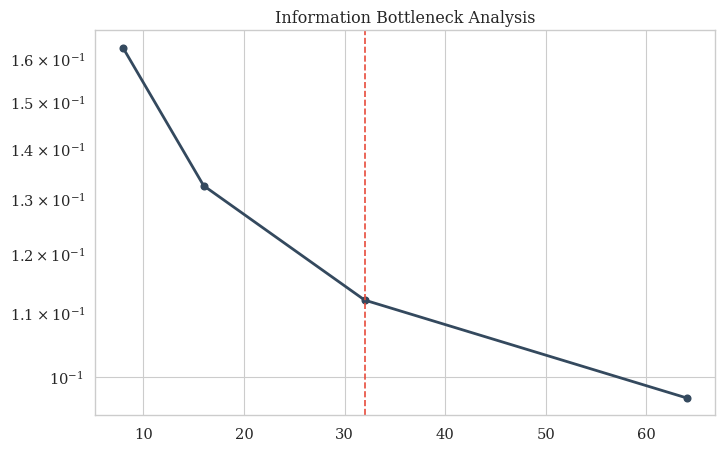

STAGE 3: Deep Representation Learning
Epoch 0 | Loss: 29.400566
Epoch 10 | Loss: 1.120901
Epoch 20 | Loss: 0.707403
Epoch 30 | Loss: 0.515930
Epoch 40 | Loss: 0.445953
Epoch 50 | Loss: 0.394212
Epoch 60 | Loss: 0.358232
Epoch 70 | Loss: 0.320665
Epoch 80 | Loss: 0.346265
Epoch 90 | Loss: 0.287499
Epoch 100 | Loss: 0.292483
Epoch 110 | Loss: 0.279230
Epoch 120 | Loss: 0.285180
Epoch 130 | Loss: 0.235174
Epoch 140 | Loss: 0.418763
Epoch 150 | Loss: 0.217759
Epoch 160 | Loss: 0.230616
Epoch 170 | Loss: 0.239226
Epoch 180 | Loss: 0.203765
Epoch 190 | Loss: 0.203400
Epoch 200 | Loss: 0.203904
Epoch 210 | Loss: 0.189821
Epoch 220 | Loss: 0.190047
Epoch 230 | Loss: 0.296242
Epoch 240 | Loss: 0.183170
Epoch 250 | Loss: 0.201828
Epoch 260 | Loss: 0.202562
Epoch 270 | Loss: 0.166736
Epoch 280 | Loss: 0.178528
Epoch 290 | Loss: 0.192063
Epoch 300 | Loss: 0.187637
Epoch 310 | Loss: 0.160919
Epoch 320 | Loss: 0.166814
Epoch 330 | Loss: 0.159762
Epoch 340 | Loss: 0.163196
Epoch 350 | Loss: 0.155380


/home/molderon/micromamba/envs/Kaon/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/molderon/micromamba/envs/Kaon/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


STAGE 5: Performance Metric Study
Metric                    | Value     
----------------------------------------
Noise Ratio               | 0.0813
Silhouette Score          | 0.6969
Davies-Bouldin            | 0.3921
Calinski-Harabasz         | 46502.5000
Trustworthiness           | 0.9975
STAGE 6: Analytical Visualization


/home/molderon/micromamba/envs/Kaon/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


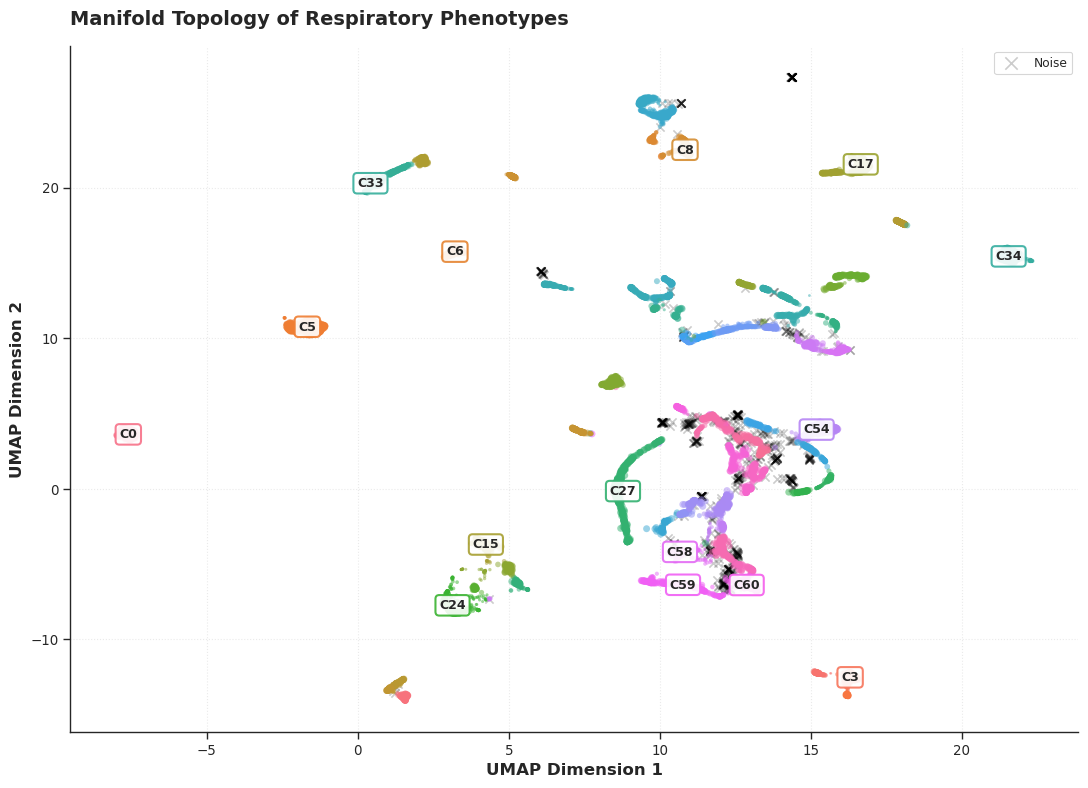

In [13]:
pipeline = DeepBreathClustering(
    target_len=200,
    latent_dim=32,
    epochs=2000,
    min_cluster_size=35
)

results = pipeline.run(Dataset)

In [ ]:
Dataset = Dataset.drop(columns = ['Target_Class_0','Target_Class_1','Target_Class_2','Target_Class_3','Target_Class_4'], axis =1)

,Breath_ID,Time_Step,Time_ms,Flow,Pressure
0,0,0,0,2.24,5.14
1,0,1,20,7.75,5.26
2,0,2,40,29.54,6.54
3,0,3,60,52.12,9.79
4,0,4,80,71.78,18.38


In [ ]:
def GetLabels_df(df, results):
    mapping_dict = dict(zip(results["processed_ids"], results["labels"]))
    df['Cluster_Label'] = df['Breath_ID'].map(mapping_dict)

    df['Cluster_Label'] = df['Cluster_Label'].fillna(-2).astype(int)
    return df

In [16]:
Dataset = GetLabels_df(Dataset,results)
Dataset.head()

,Breath_ID,Time_Step,Time_ms,Flow,Pressure,Cluster_Label
0,0,0,0,2.24,5.14,49
1,0,1,20,7.75,5.26,49
2,0,2,40,29.54,6.54,49
3,0,3,60,52.12,9.79,49
4,0,4,80,71.78,18.38,49


In [17]:
Dataset.to_csv("Dataset_Labeled.csv")